<a href="https://colab.research.google.com/github/kdkim2000/RAG2026/blob/main/%5B%EC%8B%A4%EC%8A%B5%5D_8_LangChain%EA%B3%BC_%EB%8B%A4%EC%96%91%ED%95%9C_%ED%88%B4_%EC%97%B0%EB%8F%99.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [실습] LangChain과 다양한 툴 연동하기  

LangChain의 Tool은 OpenAI의 Tool과 유사합니다.

Tool은 LLM이 답변을 출력하기 위해 활용할 수 있는 다양한 수단을 의미합니다.   
LLM은 Tool에 입력을 전달하고, 답변을 파싱하는 작업을 수행합니다.


In [ ]:
!pip install openai matplotlib langchain langchain-openai langchain-community langchain-tavily langgraph -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv(override=True)

llm = ChatOpenAI(model = 'gpt-5.2', reasoning_effort='low')

Tavily Search (http://app.tavily.com/)

Tavily Search는 1달에 1,000회 검색을 지원하는 검색 API입니다.    
구글 계정을 통해 회원가입할 수 있습니다.

In [ ]:
from langchain_tavily import TavilySearch

# TAVILY : 웹 검색을 수행하는 툴
# TAVILY_API_KEY https://app.tavily.com/home

In [ ]:
load_dotenv(override=True)

tavily_search = TavilySearch(max_results=3)

tavily_search.invoke("Gemma 4")

{'query': 'Gemma 4',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://lmstudio.ai/models/gemma-4',
   'title': 'Gemma 4',
   'content': "undefined\n\nGemma is a family of open models built by Google DeepMind. Gemma 4 models are multimodal, handling text and image input (with audio supported on small models) and generating text output. This release includes open-weights models in both pre-trained and instruction-tuned variants. Gemma 4 features a context window of up to 256K tokens and maintains multilingual support in over 140 languages. [...] Featuring both Dense and Mixture-of-Experts (MoE) architectures, Gemma 4 is well-suited for tasks like text generation, coding, and reasoning. The models are available in four distinct sizes: E2B, E4B, 26B A4B, and 31B. Their diverse sizes make them deployable in environments ranging from high-end phones to laptops and servers, democratizing access to state-of-the-art AI.\n\nGemma 4 introduces key capabi

In [ ]:
print('Tavily Search 예제:')
example_query = "Tavily Search 사용법"
search_results = tavily_search.invoke(example_query)
print(f"검색어: '{example_query}'")
for i, result in enumerate(search_results['results']):
    print(f"  결과 {i+1}:")
    print(f"    URL: {result['url']}")
    print(f"    제목: {result['title']}")
    print(f"    내용: {result['content'][:200]}...") # 내용이 길면 일부만 출력

Tavily Search 예제:
검색어: 'Tavily Search 사용법'
  결과 1:
    URL: https://docs.tavily.com/documentation/best-practices/best-practices-search
    제목: Best Practices for Search - Tavily Docs
    내용: Run queries in parallel, but cap how many run at once with a semaphore so you stay under your rate limit.
 Handle failures per query. Tag each result `ok` / `error` and retry only the failed ones with...
  결과 2:
    URL: http://www.umlcert.com/aipromptsmarteasy_professor-na_tavily
    제목: 뉴테크프라임 » Tavily – AIPromptSmarteasy 사용해 보기 – 나 교수와 글 읽기
    내용: \ \\다양한 프로그래밍 언어 지원\\: Python 라이브러리, API 호출, Langchain, LLamaIndex 등 다양한 방법으로 기존 시스템에 쉽게 통합할 수 있습니다.  
 \ \\높은 호환성\\: 다른 LLM 프레임워크와도 문제없이 연동됩니다.

\\5. 투명하고 상세한 문서 (Transparent & Informative)\\

\ \\초보...
  결과 3:
    URL: https://velog.io/@woody_ahn/Tavily-LLM%EC%9D%84-%EC%9C%84%ED%95%9C-%EC%B5%9C%EC%A0%81%ED%99%94%EB%90%9C-%EA%B2%80%EC%83%89-API
    제목: Tavily: LLM을 위한 최적화된 검색 API
    내용: # Tavily 소개

Tavily Search API는 LLM과 RAG 시스템에 최적화된 검색 엔진입니다. 기존

다양한 툴을 추가해 보겠습니다.

In [ ]:
from langchain_core.tools import tool

@tool
def calculator(expression: str) -> str:
    """수학 계산식을 입력받아 계산 결과를 반환합니다.
    사칙연산, 거듭제곱(**) 등 Python 수식을 지원합니다.

    Args:
        expression: 계산할 수식 (예: '3 + 5 * 2', '2 ** 10')
    """
    try:
        allowed_chars = set('0123456789+-*/.()**% ')
        if not all(c in allowed_chars for c in expression):
            return f'허용되지 않는 문자가 포함되어 있습니다: {expression}'
        # 주의: 교육용 코드입니다. 프로덕션에서는 ast.literal_eval 또는 numexpr을 사용하세요.
        result = eval(expression)
        return str(result)
    except Exception as e:
        return f'계산 오류: {str(e)}'

print(f"calculator('3 + 5 * 2') = {calculator.invoke({'expression': '3 + 5 * 2'})}")

@tool
def current_date() -> str:
    "현재 날짜를 %y-%m-%d 형식으로 반환합니다."
    from datetime import datetime
    return f'현재 날짜는 {datetime.now().strftime("%Y-%m-%d")} 입니다!'


print(current_date.invoke({}))

calculator('3 + 5 * 2') = 13
현재 날짜는 2026-08-04 입니다!


위에서 만든 툴을 리스트로 묶고, LLM에 binding합니다.

In [ ]:
from rich import print as rprint

tools = [tavily_search, calculator, current_date]

rprint(tools)

[
    TavilySearch(
        max_results=3,
        api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None)
    ),
    StructuredTool(
        name='calculator',
        description="수학 계산식을 입력받아 계산 결과를 반환합니다.\n    사칙연산, 거듭제곱(**) 등 Python 수식을 
지원합니다.\n\n    Args:\n        expression: 계산할 수식 (예: '3 + 5 * 2', '2 ** 10')",
        args_schema=<class 'langchain_core.utils.pydantic.calculator'>,
        func=<function calculator at 0x7e330c34ca40>
    ),
    StructuredTool(
        name='current_date',
        description='현재 날짜를 %y-%m-%d 형식으로 반환합니다.',
        args_schema=<class 'langchain_core.utils.pydantic.current_date'>,
        func=<function current_date at 0x7e330c34c860>
    )
]

In [ ]:
llm_with_tools = llm.bind_tools(tools)
llm_with_tools
rprint(llm_with_tools)

_ChatModelBinding(
    bound=ChatOpenAI(
        metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.13', 'langchain-openai': '1.4.1'}},
        output_version=None,
        profile={
            'name': 'GPT-5.2',
            'release_date': '2025-12-11',
            'last_updated': '2025-12-11',
            'open_weights': False,
            'max_input_tokens': 272000,
            'max_output_tokens': 128000,
            'text_inputs': True,
            'image_inputs': True,
            'audio_inputs': False,
            'video_inputs': False,
            'text_outputs': True,
            'image_outputs': False,
            'audio_outputs': False,
            'video_outputs': False,
            'reasoning_output': True,
            'tool_calling': True,
            'structured_output': True,
            'attachment': True,
            'temperature': False,
            'image_url_inputs': True,
            'pdf_inputs': True,
            'pdf_tool_message': True,
            'image_tool_message': True,
            'tool_choice': True,
            'tool_call_streaming': True,
            'reasoning_effort_levels': ['none', 'low', 'medium', 'high', 'xhigh']
        },
        client=<openai.resources.chat.completions.completions.Completions object at 0x7e330c89f650>,
        async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7e330c86a450>,
        root_client=<openai.OpenAI object at 0x7e330df1dc70>,
        root_async_client=<openai.AsyncOpenAI object at 0x7e330c869f10>,
        model_name='gpt-5.2',
        model_kwargs={},
        openai_api_key=SecretStr('**********'),
        openai_proxy=None,
        stream_usage=True,
        reasoning_effort='low',
        stream_chunk_timeout=120.0
    ),
    kwargs={
        'tools': [
            {
                'type': 'function',
                'function': {
                    'name': 'tavily_search',
                    'description': 'A search engine optimized for comprehensive, accurate, and trusted results. 
Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but 
offers advanced search depths, domain management, time range filters, and image search, this tool delivers 
real-time, accurate, and citation-backed results.Input should be a search query.',
                    'parameters': {
                        'properties': {
                            'query': {'description': 'Search query to look up', 'type': 'string'},
                            'include_domains': {
                                'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}],
                                'default': [],
                                'description': 'A list of domains to restrict search results to.\n\n        Use 
this parameter when:\n        1. The user explicitly requests information from specific websites (e.g., "Find 
climate data from nasa.gov")\n        2. The user mentions an organization or company without specifying the domain
(e.g., "Find information about iPhones from Apple")\n\n        In both cases, you should determine the appropriate 
domains (e.g., ["nasa.gov"] or ["apple.com"]) and set this parameter.\n\n        Results will ONLY come from the 
specified domains - no other sources will be included.\n        Default is None (no domain restriction).\n        '
                            },
                            'exclude_domains': {
                                'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}],
                                'default': [],
                                'description': 'A list of domains to exclude from search results.\n\n        Use 
this parameter when:\n        1. The user explicitly requests to avoid certain websites (e.g., "Find information 
about climate change but not from twitter.com")\n        2. The user mentions not wanting results from specific 

llm_with_tools는 llm에 tool이 결합된 형태지만, llm의 구조입니다.   
invoke를 통해 툴을 사용하도록 유도해 봅시다.

In [ ]:
# 툴 실행을 하지 않음
llm_with_tools.invoke("안녕?")

AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 1365, 'total_tokens': 1379, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1280}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-E924jHlnRDUcxkLfYbr4CrFOOfHqD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fcb43-aac5-7f81-8c0e-48dc6f636169-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1365, 'output_tokens': 14, 'total_tokens': 1379, 'input_token_details': {'audio': 0, 'cache_read': 1280}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [ ]:
llm_with_tools.invoke("너는 무슨 도구가 잇는지 소개해 줘")

AIMessage(content='내가 여기서 사용할 수 있는 “도구(tools)”는 아래 3가지야. (필요할 때 호출해서 결과를 받아 답변에 반영해.)\n\n## 1) 웹 검색: `functions.tavily_search`\n- 인터넷에서 최신/실시간 정보, 기사, 공식 문서 등을 찾아 요약할 때 사용\n- 옵션으로\n  - 특정 도메인만 검색(`include_domains`) 또는 제외(`exclude_domains`)\n  - 검색 깊이(`search_depth`: basic/advanced/fast/ultra-fast)\n  - 기간 제한(`time_range` 또는 `start_date`/`end_date`)\n  - 주제 분류(`topic`: general/news/finance)\n  - 이미지 포함 여부(`include_images`)\n- 결과를 URL/스니펫 형태로 받아서 근거와 함께 정리해줄 수 있어\n\n## 2) 계산기: `functions.calculator`\n- 사칙연산, 거듭제곱 등 **파이썬 수식 형태** 계산을 정확히 처리\n- 예: `2 ** 10`, `(3 + 5) * 2`\n\n## 3) 오늘 날짜: `functions.current_date`\n- 현재 날짜를 `YY-MM-DD` 형식으로 반환\n\n## (추가) 병렬 실행 래퍼: `multi_tool_use.parallel`\n- 위 도구들을 “여러 개 동시에” 실행해야 할 때, 한 번에 묶어서 호출하는 용도\n- 예: 웹검색 2개를 동시에 돌리거나, 검색+날짜를 같이 가져오는 식\n\n원하면 “어떤 상황에서 어떤 도구를 쓰는 게 좋은지” 예시까지 네가 하는 작업(과제/리서치/투자/코딩 등)에 맞춰서 추천해줄까?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 382, 'prompt_tokens': 1377, 'total_tokens': 1759,

In [ ]:
llm_with_tools.invoke("29392 * 23919는 뭐야?")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 1372, 'total_tokens': 1394, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-E927BmyrIve1PtpmhcxCqEiQBAWif', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fcb45-fdd6-7432-8144-702e454da250-0', tool_calls=[{'name': 'calculator', 'args': {'expression': '29392 * 23919'}, 'id': 'call_rMhsUfrTp91z6KRY14bLeqwX', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1372, 'output_tokens': 22, 'total_tokens': 1394, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0,

In [ ]:
# 툴 실행을 하지 않을 확률이 높음
llm_with_tools.invoke("양자 컴퓨터의 정의가 뭐야?")

AIMessage(content='양자 컴퓨터(quantum computer)는 **정보를 ‘큐비트(qubit)’로 표현하고, 양자역학적 현상(대표적으로 중첩과 얽힘)을 이용해 연산을 수행하는 컴퓨터**입니다.\n\n- **큐비트**: 일반 컴퓨터의 비트가 0 또는 1 중 하나라면, 큐비트는 측정되기 전까지 **0과 1의 상태가 동시에 가능한(중첩)** 형태로 표현될 수 있습니다.  \n- **얽힘**: 여러 큐비트의 상태가 서로 강하게 연결되어, 하나의 상태 변화가 다른 큐비트와 **연동된 방식으로** 기술되는 현상입니다.  \n- 이런 특성 때문에 양자 컴퓨터는 모든 문제를 더 빠르게 푸는 “만능 빠른 컴퓨터”라기보다는, **특정 문제(예: 큰 수의 소인수분해, 일부 최적화/탐색, 양자계 시뮬레이션 등)에서 매우 큰 속도 이점**을 낼 수 있는 계산 모델로 이해하는 게 정확합니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 250, 'prompt_tokens': 1372, 'total_tokens': 1622, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1280}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-E92AfiC6TNPYDt0Ml9x5EWmUhkfbV', 'service_tier': 'default', 'finis

In [ ]:
llm_with_tools.invoke("양자 컴퓨터 최신 소식 있어?")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 1371, 'total_tokens': 1446, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 19, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1280}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-E92AkhIGZse1emeqSuHEdNVQii1U2', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fcb49-59ee-7e02-80ab-bf0a765402c4-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '2026년 양자 컴퓨터 최신 소식 주요 발표 오류 정정 상용화', 'search_depth': 'advanced', 'topic': 'news', 'time_range': 'month'}, 'id': 'call_YlDIZEPeYi8ruCnOZkkJTR2u', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1371, 'output_tokens': 75, 'total_tokens': 1446,

content를 생성하는 대신에, tool_calls가 도출된 것을 볼 수 있습니다.

In [ ]:
llm_with_tools.invoke("29392 * 23919는 뭐야?").tool_calls

[{'name': 'calculator',
  'args': {'expression': '29392*23919'},
  'id': 'call_dxlgvUTstcAIZGbqE20KdvHx',
  'type': 'tool_call'}]

In [ ]:
llm_with_tools.invoke("오늘 운동을 빠질까요?").tool_calls
# No Tool Call

[]

Tool을 실행할 때, tool_call 정보를 보내면 ToolMessage 형식의 결과가 생성됩니다.   

이후, 이 내용을 메시지에 넣어서 전달하면 됩니다.

In [ ]:
calculator.invoke(llm_with_tools.invoke("29392 * 23919는 뭐야?").tool_calls[0])

ToolMessage(content='703027248', name='calculator', tool_call_id='call_Glcq0u0zN2igj0Z1VFw29tO8')

In [ ]:
# Message 전달하기 예시
from langchain.messages import HumanMessage, AIMessage, ToolMessage

question = '29392 * 23919가 뭐야?'
tool_call_msg = llm_with_tools.invoke(question)
tool_msg = calculator.invoke(tool_call_msg.tool_calls[0])

msgs = [HumanMessage(question),
       tool_call_msg,
       tool_msg]

llm_with_tools.invoke(msgs)

AIMessage(content='29392 × 23919 = **703,027,248** 입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1407, 'total_tokens': 1426, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1280}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-E92GQJ9bqHUQIYfuYDTu8Rr0SoaOu', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fcb4e-b8e2-74b2-8c1e-f99eefc5f837-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1407, 'output_tokens': 19, 'total_tokens': 1426, 'input_token_details': {'audio': 0, 'cache_read': 1280}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

### Agent(에이전트)

에이전트는 위에서 구성한 Tool Calling 과정을 반복하여 작업을 완료하는 구조입니다.   


llm 실행 --> Tool 요청 --> Tool 실행 결과 전달 --> llm 실행 --> 의 과정을 반복합니다.   

In [ ]:
tools = [calculator, tavily_search, current_date]

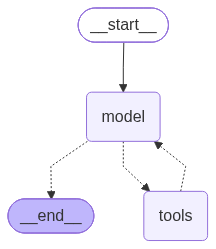

In [ ]:
from langchain.agents import create_agent

system_prompt='''툴을 사용하기 전, 툴 사용 계획에 대해 설명하고 중간 단계를 매번 간략하게 요약하세요..'''

agent = create_agent(llm, tools=tools, system_prompt= system_prompt)

agent


In [ ]:
type(agent)

langgraph.graph.state.CompiledStateGraph

In [ ]:
question = "오늘 날짜를 확인해줘."

response = agent.invoke({'messages':[HumanMessage(question)]})

response['messages'][-1].text

'오늘 날짜는 **2026-08-04**입니다.'

In [ ]:
response

{'messages': [HumanMessage(content='오늘 날짜를 확인해줘.', additional_kwargs={}, response_metadata={}, id='612586b0-2beb-478b-b68d-b94d09e3d9fa'),
  AIMessage(content='툴 사용 계획: 시스템이 제공하는 `current_date` 툴을 호출해 오늘 날짜를 확인한 뒤, 반환된 값을 그대로 알려드리겠습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 1401, 'total_tokens': 1476, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 14, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1280}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-E92eWt4goBWcfGrWBCKYOZ7WJkoHf', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fcb65-8772-70b0-aa24-05ba5ce403f5-0', tool_calls=[{'name': 'current_date', 'args': {}, 'id': 'call_TVMsOujpfTTzR1xFK6ugTYYi', 'type': 'tool_call'}], i

In [ ]:
question = "2026년 7월 출시된 DeepSeek V4 Flash 모델의 장단점을 조사해서 마크다운 표로 작성해줘."

response = agent.invoke({'messages':[HumanMessage(question)]})

response['messages'][-1].text

'| 항목 | 장점(강점) | 단점/주의점(약점) | 근거(출처) |\n|---|---|---|---|\n| 출시(2026년 7월) 성격 | 2026-07-31에 **DeepSeek-V4-Flash API가 “official release”로 공개 베타(public beta)**로 업데이트됨 | **public beta**라서 스펙/품질/가용성/동작이 운영 환경에서 변동될 수 있음(릴리스 안정성 측면) | DeepSeek API Docs Change Log(2026-07-31) https://api-docs.deepseek.com/updates |\n| 비용(가격) | **저렴한 단가**: 입력(캐시 미스) **$0.14/1M**, 출력 **$0.28/1M**, 캐시 히트 입력 **$0.0028/1M**로 대량 처리에 유리 | 저가형인 만큼(Flash 포지션) 고난도 추론/코딩/에이전트 작업에서 상위 모델 대비 품질 손해 가능 | DeepSeek Models & Pricing https://api-docs.deepseek.com/quick_start/pricing |\n| 처리량/제한(동시성) | **동시성 한도 2500**(Pro는 500)로 고트래픽 파이프라인에 유리 | 높은 동시성은 유리하지만, 실제 시스템 설계에서는 레이트리밋/격리 정책을 추가로 고려해야 함 | DeepSeek Models & Pricing https://api-docs.deepseek.com/quick_start/pricing |\n| 컨텍스트/출력 길이 | **컨텍스트 1M**, **최대 출력 384K**로 장문 문서/로그/코드베이스 입력에 유리 | 긴 컨텍스트·장문 출력은 비용/지연시간이 커질 수 있고, 장문 생성에서 반복·모순 등 품질 문제가 커질 수 있음 | DeepSeek Models & Pricing https://api-docs.deepseek.com/quick_start/pricing / (장문 품질 코멘트 사례) Kilo 테스트 https://blog.kilo.ai/p

In [ ]:
print(response['messages'][-1].text)

| 항목 | 장점(강점) | 단점/주의점(약점) | 근거(출처) |
|---|---|---|---|
| 출시(2026년 7월) 성격 | 2026-07-31에 **DeepSeek-V4-Flash API가 “official release”로 공개 베타(public beta)**로 업데이트됨 | **public beta**라서 스펙/품질/가용성/동작이 운영 환경에서 변동될 수 있음(릴리스 안정성 측면) | DeepSeek API Docs Change Log(2026-07-31) https://api-docs.deepseek.com/updates |
| 비용(가격) | **저렴한 단가**: 입력(캐시 미스) **$0.14/1M**, 출력 **$0.28/1M**, 캐시 히트 입력 **$0.0028/1M**로 대량 처리에 유리 | 저가형인 만큼(Flash 포지션) 고난도 추론/코딩/에이전트 작업에서 상위 모델 대비 품질 손해 가능 | DeepSeek Models & Pricing https://api-docs.deepseek.com/quick_start/pricing |
| 처리량/제한(동시성) | **동시성 한도 2500**(Pro는 500)로 고트래픽 파이프라인에 유리 | 높은 동시성은 유리하지만, 실제 시스템 설계에서는 레이트리밋/격리 정책을 추가로 고려해야 함 | DeepSeek Models & Pricing https://api-docs.deepseek.com/quick_start/pricing |
| 컨텍스트/출력 길이 | **컨텍스트 1M**, **최대 출력 384K**로 장문 문서/로그/코드베이스 입력에 유리 | 긴 컨텍스트·장문 출력은 비용/지연시간이 커질 수 있고, 장문 생성에서 반복·모순 등 품질 문제가 커질 수 있음 | DeepSeek Models & Pricing https://api-docs.deepseek.com/quick_start/pricing / (장문 품질 코멘트 사례) Kilo 테스트 https://blog.kilo.ai/p/we-te

In [ ]:
# 작동 과정
rprint(response)

{
    'messages': [
        HumanMessage(
            content='2026년 7월 출시된 DeepSeek V4 Flash 모델의 장단점을 조사해서 마크다운 표로 작성해줘.',
            additional_kwargs={},
            response_metadata={},
            id='013480a2-2dc4-4d84-b962-d11381c8344d'
        ),
        AIMessage(
            content='툴 사용 계획: (1) 웹 검색 툴로 “DeepSeek V4 Flash”의 2026년 7월 출시 소식과 공식/보도 자료를 
찾고, (2) 여러 출처에서 공통으로 언급되는 특징(성능, 지연시간, 비용, 컨텍스트, 멀티모달, 안전성/제한)을 추려 
장단점으로 정리한 뒤, (3) 마크다운 표로 요약하겠습니다. 이제 검색을 진행합니다.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 198,
                    'prompt_tokens': 1423,
                    'total_tokens': 1621,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 24,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': 0,
                        'cache_write_tokens': None,
                        'cached_tokens': 1280
                    }
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5.2-2025-12-11',
                'system_fingerprint': None,
                'id': 'chatcmpl-E92iWMEicrn0fvBvsGQ3MsHEm8pcL',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019fcb69-4eb9-76f2-8c84-6d423d897149-0',
            tool_calls=[
                {
                    'name': 'tavily_search',
                    'args': {
                        'query': 'DeepSeek V4 Flash July 2026 release pros cons',
                        'search_depth': 'advanced',
                        'include_images': False,
                        'time_range': None,
                        'topic': 'general'
                    },
                    'id': 'call_Du1CnfzrIS42yu8Px42WKAK5',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 1423,
                'output_tokens': 198,
                'total_tokens': 1621,
                'input_token_details': {'audio': 0, 'cache_read': 1280},
                'output_token_details': {'audio': 0, 'reasoning': 24}
            }
        ),
        ToolMessage(
            content='{"query": "DeepSeek V4 Flash July 2026 release pros cons", "follow_up_questions": null, 
"answer": null, "images": [], "results": [{"url": "https://deepseek.ai/deepseek-v4-flash-review", "title": 
"DeepSeek V4 Flash Review (2026) — Specs, Tests & Speed", "content": "### Pros\\n\\n• Massive 1M context 
length\\n\\n• MIT license — fully open\\n\\n• Incredibly cheap pricing\\n\\n• Flash model punches above its 
weight\\n\\n• Strong on 360° / 3D rotational tasks\\n\\n### Cons\\n\\n• Feels \\"benchmark maxed\\"\\n\\n• Sloppy 
real-world execution\\n\\n• Lags behind GLM 5.1 & Qwen 3.6 Plus\\n\\n• Front-end output looks dated\\n\\n• Pro 
model fails complex agentic flows\\n\\nWhile the pricing, context length, and efficiency make DeepSeek V4 an 
incredible base for future development, this preview version needs serious refinement. At the end of the day, 
cheaper doesn\'t make it better — it just means it\'s cheaper.\\n\\n## Try DeepSeek in your browser\\n\\nAccess 
DeepSeek V4 and other models directly from any webpage with the AI Sidebar Chrome Extension.\\n\\nInstall AI 
Sidebar\\n\\n## Related Reading\\n\\n### Explore Our Content [...] Heads up — deprecation: the legacy 
`deepseek-chat` and `deepseek-reasoner` model ids will be deprecated on 2026-07-24. They map to V4 Flash\'s 
non-thinking and thinking modes respectively, so plan a migration to `deepseek-v4-flash` or `deepseek-v4-pro` well 
before that dat

스트리밍을 통해, 단계별 작업 과정도 확인합니다.

In [ ]:
def stream_agent(agent, input_msgs, config=None):
    """에이전트 실행을 스트리밍하며 각 스텝을 출력합니다."""
    def _format_arg(v):
        s = repr(v) if not isinstance(v, str) else v
        return s if len(s) <= 200 else s[:197] + "..."

    last_msg = None
    for chunk in agent.stream(input_msgs, config=config, stream_mode="updates"):
        for step, data in chunk.items():
            msg = data['messages'][-1]
            content = msg.text if hasattr(msg, 'text') else str(msg.content)
            print(f"[{step}]")
            if len(content) > 1000:
                print(f"  content: {content[:800]}...(중략)")
            else:
                print(f"  content: {content}")
            if hasattr(msg, 'tool_calls') and msg.tool_calls:
                calls = []
                for tc in msg.tool_calls:
                    args_str = ", ".join(f"{k}={_format_arg(v)}" for k, v in tc['args'].items())
                    calls.append(f"{tc['name']}({args_str})")
                print(f"  tool_calls: {calls}")
            print()
            last_msg = msg
    return last_msg

In [ ]:
question = {'messages':[HumanMessage('오늘 날짜가 어떻게 되니?')]}

result = stream_agent(agent, question)

[model]
  content: 툴 사용 계획: 시스템의 현재 날짜를 정확히 확인하기 위해 `current_date` 툴을 1회 호출하겠습니다.  
중간 단계 요약: 툴로 오늘 날짜를 조회합니다.
  tool_calls: ['current_date()']

[tools]
  content: 현재 날짜는 2026-08-04 입니다!

[model]
  content: 오늘 날짜는 **2026-08-04**입니다.



### 토큰 단위 스트리밍

stream_mode="updates"는 각 스텝이 끝난 시점의 결과를 한 번에 돌려줍니다.  
답변이 생성되는 과정을 토큰 단위로 확인하기 위해, stream_utils.py를 사용합니다.

- stream_print: 토큰과 도구 호출 기록을 print로 출력
- stream_with_markdown: 토큰을 누적해 마크다운으로 렌더링

In [ ]:
from stream_utils import stream_print, stream_with_markdown

In [ ]:
result = await stream_print(agent, '오늘 날짜를 확인하고, 올해가 며칠 남았는지 계산해줘. 계산기 출로 정확한 값을 구해.')

툴 사용 계획:  
1) `current_date`로 오늘 날짜를 정확히 확인합니다.  
2) 확인한 날짜를 기준으로, 올해(12/31)까지 “오늘을 제외하고” 남은 일수를 파이썬 `datetime` 계산식으로 `calculator`에 넣어 정확한 값을 구합니다.
🔧 Tool 호출: current_date  {}
✅ Tool 결과: 현재 날짜는 2026-08-04 입니다!
중간 요약: 오늘 날짜는 2026-08-04로 확인되었습니다. 이제 2026-12-31까지 남은 일수를 계산기로 정확히 계산하겠습니다.
🔧 Tool 호출: calculator  {'expression': 'import datetime as dt\n(dt.date(2026,12,31)-dt.date(2026,8,4)).days'}
✅ Tool 결과: 허용되지 않는 문자가 포함되어 있습니다: import datetime as dt
(dt.date(2026,12,31)-dt.date(2026,8,4)).days
툴 사용 계획 수정: 계산기에서 `import`가 제한되어 있어, 달별 남은 날짜를 합산하는 산술식으로 정확히 계산하겠습니다(8월 남은 일수 + 9~12월 전체 일수).
🔧 Tool 호출: calculator  {'expression': '(31-4) + 30 + 31 + 30 + 31'}
✅ Tool 결과: 149
툴 사용 계획:  
1) `current_date`로 오늘 날짜를 확인  
2) 계산기(`calculator`)로 올해 12/31까지 남은 일수를 정확히 산술로 계산

중간 요약: 오늘 날짜는 **2026-08-04**입니다.

- 오늘 날짜: **2026-08-04**
- 올해(2026년) 남은 일수(오늘 제외, 12/31까지):
  - 8월 남은 날: 31-4 = 27일  
  - 9~12월: 30 + 31 + 30 + 31 = 122일  
  - 합계: 27 + 122 = **149일**

결론: **올해는 149일 남았습니다.**


### 마크다운 렌더링 스트리밍

In [ ]:
result = await stream_with_markdown(agent, 'LangChain의 create_agent가 제공하는 기능을 검색해서 마크다운 표로 정리해줘.')

툴 사용 계획:
1) Tavily 검색으로 LangChain에서 `create_agent`(또는 이에 상응하는 에이전트 생성 헬퍼) 문서/소스/가이드를 찾아 핵심 기능과 파라미터를 수집합니다.  
2) 결과를 교차 확인해 “무엇을 제공하는지(기능)”를 항목화한 뒤, 마크다운 표로 정리하고 각 항목에 근거 링크를 붙입니다.

🔧 Tool 호출: `tavily_search` (인자: `{'query': 'LangChain create_agent function features parameters', 'search_depth': 'advanced', 'include_images': False, 'topic': 'general'}`)

✅ 결과: {"query": "LangChain create_agent function features parameters", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://github.com/langchain-ai/langchain/issues/33732"

중간 요약: LangChain 공식 레퍼런스에 `create_agent` API 문서가 있으며, 파라미터(모델, 툴, 시스템 프롬프트, 미들웨어, 응답 포맷, 상태/컨텍스트 스키마, 체크포인터, 스토어 등) 목록을 확인했습니다. 이제 추가 검색으로 `interrupt_before/after`, `debug`, `cache` 같은 기능 의미를 보강하고, 표로 정리하겠습니다.

🔧 Tool 호출: `tavily_search` (인자: `{'query': 'reference.langchain.com create_agent interrupt_before interrupt_after debug cache checkpointer store middleware', 'search_depth': 'advanced', 'topic': 'general'}`)

✅ 결과: {"query": "reference.langchain.com create_agent interrupt_before interrupt_after debug cache checkpointer store middleware", "follow_up_questions": null, "answer": null, "images": [], "results": [{"ur


---
| 기능(무엇을 해주나) | 관련 파라미터/입력 | 설명 | 근거 |
|---|---|---|---|
| 에이전트를 “그래프 형태”로 생성/컴파일 | 반환값: `CompiledStateGraph[...]` | `create_agent`는 에이전트를 LangGraph 기반의 실행 그래프(컴파일된 StateGraph)로 만들어, 실행/중단/체크포인트 등 그래프 기능을 활용하게 해줍니다. | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 모델 지정(문자열 ID 또는 모델 인스턴스) | `model: str \| BaseChatModel` | `"openai:..."` 같은 문자열 식별자 또는 `ChatOpenAI` 등 채팅 모델 인스턴스를 받아 에이전트의 LLM을 결정합니다. | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 툴(도구) 장착 | `tools: Sequence[BaseTool \| Callable \| dict] \| None` | 에이전트가 호출할 수 있는 툴을 주입합니다(툴 객체/함수/스키마 dict 등 허용). | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 시스템 프롬프트 설정 | `system_prompt: str \| SystemMessage \| None` | 에이전트의 기본 지시문/역할을 시스템 메시지로 설정합니다. | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 실행 흐름에 개입하는 미들웨어(핵심 확장 포인트) | `middleware: Sequence[AgentMiddleware[...]]` | 에이전트 실행 과정에 “가로채기/전후처리/제어” 레이어를 삽입하는 확장 포인트를 제공합니다. | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 구조화 응답(출력 포맷) 지정 | `response_format: ResponseFormat \| type \| dict \| None` | 모델 출력 형식을 구조화(스키마/타입 등)하도록 지정하는 옵션입니다. | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 상태(State) 스키마 커스터마이즈 | `state_schema: type[AgentState[...]] \| None` | 그래프가 누적/전달하는 상태 객체의 스키마(타입)를 사용자 정의로 바꿀 수 있습니다. | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 컨텍스트(Context) 스키마 주입 | `context_schema: type[ContextT] \| None` | 실행 시 외부에서 주입되는 컨텍스트 타입(예: 클라이언트/핸들 등)을 정의할 수 있습니다. | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 체크포인팅(대화/스레드 단위 상태 영속화) | `checkpointer: Checkpointer \| None` | 단일 스레드(예: 한 대화 thread)의 그래프 상태를 저장/복원하는 체크포인터를 연결합니다. | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 스토어(스레드 간 공유 저장소) | `store: BaseStore \| None` | 여러 스레드/대화 간에 공유되는 데이터 저장소를 연결합니다(장기 기억/프로필 등). | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 특정 노드 “실행 전” 인터럽트(중단) | `interrupt_before: list[str] \| None` | 지정한 노드 실행 **직전**에 중단할 수 있어, 툴 실행 전 사용자 승인 같은 UX를 넣기 좋습니다. | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 특정 노드 “실행 후” 인터럽트(중단) | `interrupt_after: list[str] \| None` | 지정한 노드 실행 **직후**에 중단해, 결과를 즉시 반환하거나 후처리 파이프라인으로 넘기는 흐름을 만들 수 있습니다. | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 디버그 로깅 | `debug: bool` | 그래프 실행을 verbose하게 로깅하도록 켭니다. | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 에이전트(그래프) 이름 지정 | `name: str \| None` | 생성되는 그래프의 식별 이름을 부여합니다(다른 그래프에 서브그래프로 넣을 때도 유용). | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 캐싱 | `cache: BaseCache[Any] \| None` | 그래프 실행 결과를 캐시해 재실행/중복 호출 비용을 줄이는 옵션입니다. | https://reference.langchain.com/python/langchain/agents/factory/create_agent |
| 변환기(Transformers) 체인 연결 | `transformers: Sequence[TransformerFactory] \| None` | 에이전트 그래프에 적용할 변환(전처리/후처리 등) 팩토리 시퀀스를 추가할 수 있습니다. | https://reference.langchain.com/python/langchain/agents/factory/create_agent |

원하시면, 위 기능들을 **“사용 시나리오(예: 승인형 툴 호출, 장기 기억, 구조화 출력)”** 기준으로 다시 묶어서 표를 재구성해드릴까요?

### 대화 메모리(Checkpointer)

지금까지의 에이전트는 invoke를 호출할 때마다 빈 메시지 목록에서 시작하므로, 직전 대화를 참조하지 못합니다.  
대화를 이어가려면 체크포인터를 연결해 매 스텝의 상태를 저장하도록 합니다.  

create_agent의 checkpointer 인자에 InMemorySaver를 전달하면 상태가 메모리에 보관됩니다.  
보관된 상태는 config의 thread_id로 구분하므로, 같은 thread_id로 호출한 대화끼리 메시지가 이어집니다.

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver

memory_agent = create_agent(
    llm,
    tools=tools,
    system_prompt='주어진 도구를 사용하여 질문에 답변하세요. 앞선 대화에서 확인한 정보는 다시 묻지 말고 활용하세요.',
    checkpointer=InMemorySaver(),
)

config = {'configurable': {'thread_id': 'session-1'}}

In [ ]:
first = memory_agent.invoke(
    {'messages': [HumanMessage('내 이름은 김민준이고, 서울에서 데이터 분석 업무를 하고 있어.')]},
    config=config,
)

print(first['messages'][-1].text)

알겠습니다. 앞으로 대화에서 **김민준님**(서울 거주, **데이터 분석 업무**) 정보를 기준으로 답변을 더 맞춤형으로 드릴게요.  
원하시면 현재 하시는 분석 도메인(예: 커머스/마케팅/금융/제조)이나 주로 쓰는 도구(SQL, Python, Tableau 등)에 맞춰서도 도움 드릴 수 있어요.


In [ ]:
second = memory_agent.invoke(
    {'messages': [HumanMessage('내 이름과 하는 일을 다시 알려줘.')]},
    config=config,
)

print(second['messages'][-1].text)

김민준님이고, 서울에서 데이터 분석 업무를 하고 있어요.


get_state로 특정 thread_id에 보관된 상태를 조회하면, 지금까지 오간 메시지 전체를 확인할 수 있습니다.

In [ ]:
state = memory_agent.get_state(config)

for message in state.values['messages']:
    print(f'{type(message).__name__}: {message.text}')

HumanMessage: 내 이름은 김민준이고, 서울에서 데이터 분석 업무를 하고 있어.
AIMessage: 알겠습니다. 앞으로 대화에서 **김민준님**(서울 거주, **데이터 분석 업무**) 정보를 기준으로 답변을 더 맞춤형으로 드릴게요.  
원하시면 현재 하시는 분석 도메인(예: 커머스/마케팅/금융/제조)이나 주로 쓰는 도구(SQL, Python, Tableau 등)에 맞춰서도 도움 드릴 수 있어요.
HumanMessage: 내 이름과 하는 일을 다시 알려줘.
AIMessage: 김민준님이고, 서울에서 데이터 분석 업무를 하고 있어요.


thread_id를 바꾸면 별도의 상태에서 대화가 시작되므로, 앞선 두 번의 대화는 참조되지 않습니다.

In [ ]:
new_config = {'configurable': {'thread_id': 'session-2'}}

third = memory_agent.invoke(
    {'messages': [HumanMessage('내 이름과 하는 일을 다시 알려줘.')]},
    config=new_config,
)

print(third['messages'][-1].text)

지금 대화 기록만으로는 당신의 **이름**과 **하는 일(직업/업무)** 정보를 확인할 수 없어요. 이전에 그 내용을 공유한 기록이 이 세션에 남아있지 않습니다.

원하시면 아래처럼 알려주면, 다음부터는 이 대화 안에서 그대로 불러드릴게요.
- 이름:
- 하는 일(직업/역할):


stream_with_markdown에 config를 함께 지정하면 astream_events로 그대로 전달되므로, 메모리를 연결한 에이전트에도 같은 방식으로 사용합니다.

In [ ]:
result = await stream_with_markdown(memory_agent, '내 이름으로 삼행시를 지어줘.', config=config)

김: 김민준님의 데이터 감각은 숫자 속에서 패턴을 찾아내고  
민: 민첩하게 인사이트를 뽑아 팀의 방향을 잡아주며  
준: 준비된 분석으로 서울에서 결과를 더 좋게 만듭니다

### 정리

- stream_print, stream_with_markdown: astream_events로 토큰과 도구 실행을 실시간 출력하는 stream_utils.py의 헬퍼
- InMemorySaver: 대화 상태를 메모리에 보관하는 체크포인터
- thread_id: 하나의 대화 세션을 구분하는 키
- get_state: 특정 thread_id에 보관된 메시지 전체를 조회하는 메서드

InMemorySaver는 커널이 종료되면 보관하던 상태도 함께 사라집니다.  
대화를 파일이나 데이터베이스에 남기려면 SqliteSaver, PostgresSaver를 사용합니다.

## [실습] 유용한 툴 3개 추가하기

아래의 툴을 그대로 구성하거나 개선하고, LLM에 연결하여 실행해 봅시다.

In [ ]:
import os

BLOCKED_FILES = ['env', '.env', 'credentials', '.secret', 'id_rsa', '.pem']


def _resolve_within_base(file_path: str, base_dir: str | None = None) -> str | None:
    """file_path가 base_dir(기본: 현재 작업 디렉터리) 트리 안에 있으면
    정규화된 절대 경로를 반환, 벗어나면 None."""
    base = os.path.realpath(base_dir or os.getcwd())
    target = os.path.realpath(file_path)        # .. 및 심볼릭 링크까지 해소
    try:
        if os.path.commonpath([base, target]) == base:
            return target
    except ValueError:
        pass  # 서로 다른 드라이브(Windows) 등 비교 불가한 경우
    return None


def _is_blocked_name(file_path: str) -> bool:
    base = os.path.basename(file_path)
    return base in BLOCKED_FILES or any(file_path.endswith(b) for b in BLOCKED_FILES)


@tool
def read_file(file_path: str) -> str:
    """파일 내용을 읽습니다. file_path: 파일 경로"""
    if _is_blocked_name(file_path):
        return f"보안 정책에 의해 '{os.path.basename(file_path)}' 파일은 읽을 수 없습니다."
    safe = _resolve_within_base(file_path)
    if safe is None:
        return "보안 정책에 의해 현재 작업 디렉터리 밖의 파일은 읽을 수 없습니다."
    try:
        text = open(safe, encoding='utf-8').read()
        return text[:10000] + ('\n... (truncated)' if len(text) > 10000 else '')
    except Exception as e:
        return f'파일 읽기 오류: {e}'


@tool
def write_file(file_path: str, content: str) -> str:
    """파일에 내용을 작성. file_path: 경로, content: 작성할 내용"""
    if _is_blocked_name(file_path):
        return f"보안 정책에 의해 '{os.path.basename(file_path)}' 파일은 쓸 수 없습니다."
    safe = _resolve_within_base(file_path)        # makedirs 전에 검증
    if safe is None:
        return "보안 정책에 의해 현재 작업 디렉터리 밖에는 저장할 수 없습니다."
    try:
        d = os.path.dirname(safe)
        if d:
            os.makedirs(d, exist_ok=True)
        with open(safe, 'w', encoding='utf-8') as f:
            f.write(content)
        return f'파일 작성 완료: {safe} ({len(content)}자)'
    except Exception as e:
        return f'파일 작성 오류: {e}'

In [ ]:
from langchain_community.document_loaders import WebBaseLoader

@tool
def fetch_url(url: str) -> str:
    """URL의 웹페이지 내용을 가져옵니다. url: http(s):// 웹페이지 URL"""
    if not url.startswith(('http://', 'https://')):
        return f'오류: http(s):// URL만 지원합니다. 받은 값: {url}'
    try:
        docs = WebBaseLoader(url).load()
        content = docs[0].page_content if docs else '내용을 가져올 수 없습니다.'
        return content[:5000]
    except Exception as e:
        return f'fetch_url 오류: {type(e).__name__}: {e}'


/tmp/ipykernel_1280/531958482.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader


Draw Image Tool: API 인증에 따라 실행 어려울 수 있음

In [ ]:
import base64
from zoneinfo import ZoneInfo
from datetime import datetime
from pathlib import Path
from IPython.display import Image

@tool
def draw_image(prompt:str) ->str:
    """
    텍스트 프롬프트를 기반으로 AI 이미지를 생성하고 로컬에 저장합니다.

    이 도구는 사용자가 이미지 생성, 그림 그리기, 시각적 콘텐츠 제작을
    요청할 때 사용합니다. 내부적으로 GPT 이미지 생성 모델을 호출합니다.

    Args:
        prompt (str): 생성할 이미지를 설명하는 텍스트.
            구체적이고 상세할수록 결과물 품질이 향상됩니다.

    Returns:
        str: 생성된 이미지의 저장 경로를 포함한 결과 메시지.
            성공 시 "✅ Image saved: outputs/generated_images/image_YYYYMMDD_HHMMSS_mmm.png" 형식.

    Note:
        - 이미지는 outputs/nano_banana2/ 디렉토리에 타임스탬프 기반 파일명으로 저장됨
        - 출력 형식: PNG
    """
    llm = ChatOpenAI(model="gpt-5.2", reasoning_effort='low')
    tool = {"type": "image_generation", "model": "gpt-image-2"}
    llm_with_tools = llm.bind_tools([tool])
    ai_message = llm_with_tools.invoke(prompt)

    image = next(item for item in ai_message.content_blocks if item["type"] == "image")

    kst = ZoneInfo("Asia/Seoul")
    ts = datetime.now(kst).strftime("%Y%m%d_%H%M%S_%f")[:-3]  # 밀리초까지
    out_dir = Path("outputs") / "generated_images"
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / f"image_{ts}.png"
    out_path.write_bytes(base64.b64decode(image["base64"]))

    # (선택) 노트북에서 바로 보고 싶으면 주석 해제
    display(Image(filename=str(out_path)))

    return f"✅ Image saved: {out_path.as_posix()}"

# [실습] ReAct Agent에 새로운 도구 추가하기

아래 조건에 맞는 에이전트를 만들어보세요:

1. 새로운 도구를 1개 이상 추가
2. 에이전트에 적합한 시스템 프롬프트 작성
3. 여러 도구를 조합해야 하는 질문으로 테스트

## LangChain 에이전트 생성

In [ ]:
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage

# 모든 도구를 하나의 리스트로 묶습니다.
tools = [
    tavily_search,
    calculator,
    current_date,
    read_file,
    write_file,
    fetch_url,
    draw_image
]

# 에이전트의 동작을 안내하는 시스템 프롬프트
system_prompt = '''당신은 유용한 AI 비서입니다. 사용자 요청에 따라 적절한 도구를 사용하여 답변을 생성합니다.
각 툴을 사용하기 전에, 툴 사용 계획에 대해 설명하고 중간 단계를 매번 간략하게 요약하세요.
사용 가능한 도구는 다음과 같습니다:
- tavily_search: 웹 검색
- calculator: 수학 계산
- current_date: 현재 날짜 확인
- read_file: 파일 내용 읽기
- write_file: 파일에 내용 작성
- fetch_url: 웹페이지 내용 가져오기
- draw_image: 텍스트 프롬프트로 이미지 생성
'''



LangChain 에이전트가 성공적으로 생성되었습니다!


In [ ]:
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    llm,
    tools=tools,
    system_prompt=system_prompt,
    checkpointer=InMemorySaver(),
)
config = {'configurable': {'thread_id': 'session-1'}}

In [ ]:
result = await stream_with_markdown(agent, '너는무슨도구가 있니?', config=config)

제가 사용할 수 있는 도구는 아래 7가지입니다. (필요할 때만 선택해서 씁니다.)

1) **tavily_search**: 웹 검색(최신 정보/자료 찾기)  
2) **calculator**: 수학 계산(사칙연산, 거듭제곱 등)  
3) **current_date**: 현재 날짜 확인(YY-MM-DD 형식)  
4) **read_file**: 파일 내용 읽기  
5) **write_file**: 파일에 내용 저장/작성  
6) **fetch_url**: 특정 URL 웹페이지 내용 가져오기  
7) **draw_image**: 텍스트 설명으로 이미지 생성해서 파일로 저장

원하시면 “어떤 작업(예: 뉴스 요약, 계산, 파일 정리, 이미지 생성 등)”을 할지 말해주면 그에 맞는 도구로 진행할게요.

In [ ]:
result = await stream_print(agent, '너는무슨도구가 있니?', config=config)

제가 사용할 수 있는 도구는 다음 7가지예요.

- **tavily_search**: 웹 검색(최신 정보 포함)
- **calculator**: 수학 계산
- **current_date**: 현재 날짜 확인(YY-MM-DD)
- **read_file**: 파일 내용 읽기
- **write_file**: 파일에 내용 작성/저장
- **fetch_url**: 특정 URL의 웹페이지 내용 가져오기
- **draw_image**: 텍스트로 이미지 생성 후 저장

원하시면 “지금 무엇을 하고 싶은지”를 말해주면, 거기에 맞는 도구를 골라서 진행할게요.


도구 사용 계획: (1) **current_date**로 오늘 날짜를 확인하고, (2) **tavily_search**로 “오늘 KBO 선발투수 매치업”을 신뢰 가능한 출처에서 수집한 뒤, (3) 수집한 매치업을 텍스트로 정리해 **draw_image**로 인포그래픽을 생성하겠습니다. 이제 1)~2)를 먼저 병렬로 실행하겠습니다.
🔧 Tool 호출: tavily_search  {'query': '오늘 KBO 선발투수 매치업', 'search_depth': 'advanced', 'topic': 'general', 'time_range': 'day'}

🔧 Tool 호출: current_date  {}
✅ Tool 결과: 현재 날짜는 2026-08-04 입니다!
✅ Tool 결과: {"query": "오늘 KBO 선발투수 매치업", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://x10sports.tistory.com/103", "title": "8월 4일 KBO 전 경기 분석｜예고 선발·타격·불펜·엔트리·XPI", "cont
도구 사용 계획: 검색 결과에 있는 기사에서 **오늘(2026-08-04) KBO 5경기 선발투수 매치업**을 정확히 추출하기 위해 **fetch_url**로 원문을 가져온 뒤, 그 매치업을 한 장짜리 카드형 레이아웃으로 구성해 **draw_image**로 인포그래픽을 생성하겠습니다. 먼저 기사 원문을 가져오겠습니다.
🔧 Tool 호출: fetch_url  {'url': 'https://www.topstarnews.net/news/articleView.html?idxno=16154262'}
✅ Tool 결과: 










KBO 프로야구, 4일 경기 중계 일정→선발 투수? | 김효진 기자 | 톱스타뉴스








































































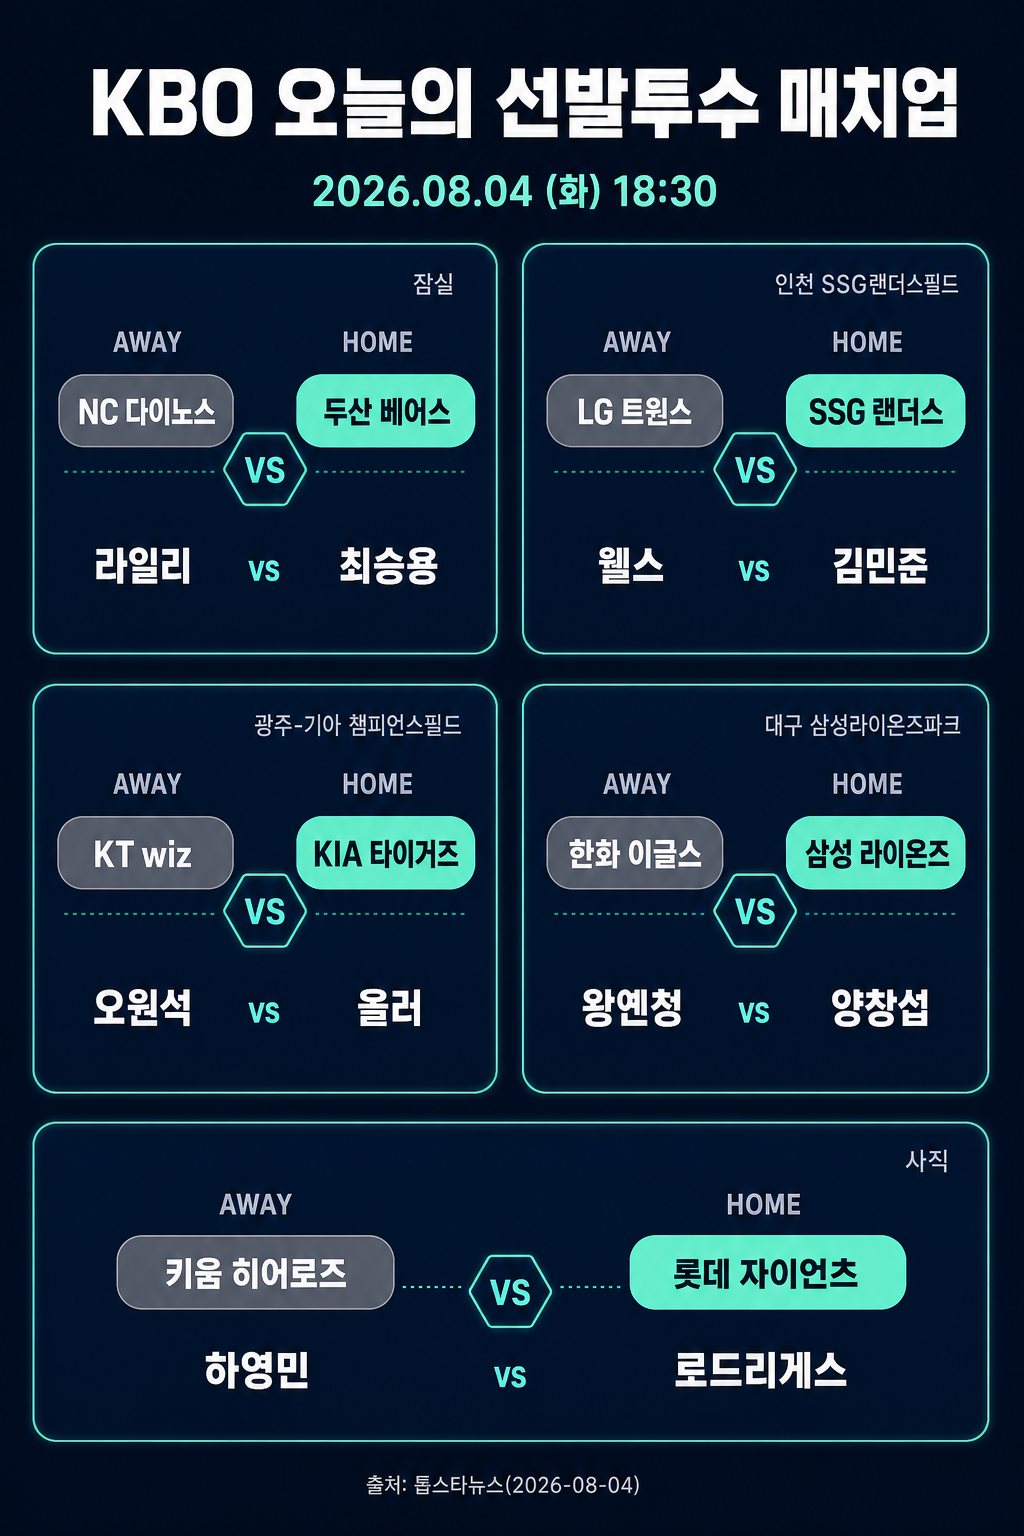

✅ Tool 결과: ✅ Image saved: outputs/generated_images/image_20260804_161649_734.png
중간 단계 요약: 오늘 날짜(2026-08-04)를 확인했고, 웹에서 오늘 KBO 5경기 **선발투수 매치업**을 수집한 뒤 그 정보를 기반으로 인포그래픽을 생성했습니다.

도구 사용 계획: (1) 오늘자 선발 매치업 데이터를 웹에서 확인 → (2) 5경기 매치업을 카드형 레이아웃으로 구성 → (3) 이미지 생성 도구로 인포그래픽 제작.

인포그래픽 생성 결과 파일:
- ✅ `outputs/generated_images/image_20260804_161649_734.png`

매치업 출처: 톱스타뉴스(2026-08-04) 기사 기준.


In [ ]:
result = await stream_print(agent, '''오늘 한국 프로야구 경기의 선발투수 매치업 자료를 바탕으로 인포그래픽을 생성해 줘.''', config=config)

### 에이전트 테스트

In [ ]:
config = {'configurable': {'thread_id': 'session-3'}}
result = await stream_print(agent,
                            '''최신 RAG 관련 설명 샘플을 만들고 싶다. 최신 기술과 예제를 포함하여 프로그램을 생성해 줘.''',
                            config=config)

최신 RAG(검색증강생성) 트렌드와 예제 코드를 반영하기 위해, 먼저 웹에서 “2024~2026년 RAG 최신 기법(예: GraphRAG, Agentic RAG, HyDE, reranking, contextual compression, RAG 평가)” 관련 문서를 검색한 뒤, 그 내용을 바탕으로 실행 가능한 Python 샘플 프로젝트(인덱싱 + 질의 + 재랭킹 + 인용/근거 출력 + 간단 평가)를 구성하겠습니다. 이제 웹 검색을 수행합니다.
🔧 Tool 호출: tavily_search  {'query': '2024 2025 최신 RAG 기법 GraphRAG agentic RAG HyDE reranking contextual compression RAGAS 문서', 'search_depth': 'advanced', 'topic': 'general', 'time_range': 'year'}
✅ Tool 결과: {"query": "2024 2025 최신 RAG 기법 GraphRAG agentic RAG HyDE reranking contextual compression RAGAS 문서", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://ragflow.io/
검색 결과를 바탕으로, (1) 최신 RAG 패턴(Agentic RAG, GraphRAG, HyDE, reranking, contextual compression, cross-granularity/parent-child) 요약을 포함하고, (2) 로컬 문서로 동작하는 실행 가능한 Python 샘플 프로젝트를 작성하겠습니다. 구현은 “하이브리드 검색(BM25+벡터) → 재랭킹 → 컨텍스트 압축 → 근거 인용 → (선택) RAGAS로 간단 평가” 흐름으로 구성하되, GraphRAG/Agentic RAG는 ‘작동하는 미니 버전’(예: 엔티티 추출 후 그래프 기반 확장 검색, 반복 검색 루프)을 넣겠습니다.  
이

In [ ]:
result = await stream_print(agent,
                            '''아래 작업을 추가해 줘.
                            ---
                            1) 문서 포맷(PDF/HTML/Notion 등) 추가,
2) 한국어 NER/관계추출로 GraphRAG 품질 개선,
3) RAGAS 평가 스크립트(`evaluate.py`)까지 붙인 “데모 패키지”
로 확장해서 드릴게요. 어떤 도메인(예: 사내 규정, 기술 문서, 계약서, 논문) 문서로 샘플을 만들지 알려주시면 그에 맞춰 튜닝해드릴 수 있습니다.
.''',
                            config=config)

요청하신 3가지를 “데모 패키지”로 확장하기 위해 다음 순서로 작업하겠습니다.  
1) **문서 로더 확장**: HTML(BeautifulSoup) + Notion export(마크다운/HTML/간단 JSON) + PDF(기존) 지원으로 `rag/io.py`를 개선하고, ingest 단계에서 자동 인식하게 만듭니다.  
2) **한국어 NER/관계추출 기반 Mini-GraphRAG 개선**: `kiwipiepy`(경량 한국어 형태소/명사 추출) 기반 엔티티 추출기를 추가하고, 문장 단위 co-occurrence로 간단 관계(edge)까지 만들어 그래프 확장 품질을 올립니다.  
3) **RAGAS 평가 스크립트 추가**: `evaluate.py`를 추가해 “질문 리스트 → RAG로 답변/컨텍스트 수집 → RAGAS 지표 계산”이 가능하도록 만듭니다. (RAGAS는 보통 LLM/임베딩이 필요하므로 OpenAI 키가 있으면 완전 동작)\n\n이제 파일들을 수정/추가하겠습니다.
🔧 Tool 호출: write_file  {'file_path': 'rag_latest_sample/requirements.txt', 'content': 'numpy\nscikit-learn\nrank-bm25\ntqdm\npydantic\npython-dotenv\nsentence-transformers\n# document formats\npypdf\nbeautifulsoup4\nlxml\n# korean NER-ish (entity extraction)\nkiwipiepy\n# optional LLM\nopenai>=1.0.0\n# eval\nragas\ndatasets\npandas\n'}
✅ Tool 결과: 파일 작성 완료: /content/rag_latest_sample/requirements.txt (229자)

🔧 Tool 호출: write_file  {'file_path': 'rag_latest_sample/rag/io.py', 'content': 'from __future_

In [ ]:
result = await stream_print(agent,
                            '''아래 작업을 추가해 줘.
                            ---
                            원하시면 다음도 같이 튜닝해 줘
- “사내 규정/계약서/논문” 중 어떤 도메인인지에 맞춰 **청킹 규칙(조항/섹션/표·캡션 유지)** 과 **BM25 vs dense 가중치**, **엔티티 stopword/용어사전**을 조정해 성능이 확 좋아집니다.  .''',
                            config=config)

도메인별(사내 규정/계약서/논문) 튜닝을 “코드 옵션으로 선택”할 수 있도록 확장하겠습니다. 작업 계획은 다음과 같습니다.  
1) **도메인 프로필 추가**: `rag/domain_profiles.py`에 도메인별 기본값(청킹 규칙, BM25 vs dense 가중치, 엔티티 stopword/용어사전)을 정의합니다.  
2) **청킹 규칙 개선**: `rag/chunking.py`에 도메인별 청킹(조항/섹션/표·캡션 보존)을 추가하고 `ingest.py`에서 `--domain` 인자를 받아 적용합니다.  
3) **하이브리드 가중치 튜닝**: `config.py`/`pipeline.py`에서 dense/bm25 가중치를 도메인 프로필로 주입 가능하게 합니다.  
4) **엔티티 stopword/용어사전 적용**: `rag/graph.py`에서 stopword 및 glossary(강제 엔티티) 적용 옵션을 추가하고, `query.py/evaluate.py`에서도 `--domain`을 받아 동일하게 동작하게 합니다.  

이제 필요한 파일을 추가/수정하겠습니다.
🔧 Tool 호출: write_file  {'file_path': 'rag_latest_sample/rag/domain_profiles.py', 'content': 'from __future__ import annotations\n\nfrom dataclasses import dataclass, field\nfrom typing import Dict, List, Optional\n\n\n@dataclass\nclass DomainProfile:\n    name: str\n\n    # Chunking strategy\n    chunk_strategy: str  # "generic" | "regulation" | "contract" | "paper"\n\n    # Hybrid retrieval weights\n    weight_dense: float = 0.6\n    weight_bm25: floa

In [ ]:
result = await stream_print(agent,
                            '''논문(paper)''',
                            config=config)

논문(paper) 도메인에 맞춰 **(1) 섹션/캡션 보존 청킹을 더 정교화**, **(2) 하이브리드 가중치와 컨텍스트 압축 파라미터를 논문용으로 조정**, **(3) GraphRAG 엔티티 stopword/용어사전(glossary)을 논문 관행(섹션명/약어/인용표기) 기준으로 개선**하겠습니다.  
이 변경은 `rag/domain_profiles.py`와 `rag/chunking.py` 중심으로 반영하고, 마지막에 실행 예시를 정리하겠습니다. 이제 파일을 업데이트하겠습니다.
🔧 Tool 호출: write_file  {'file_path': 'rag_latest_sample/rag/domain_profiles.py', 'content': 'from __future__ import annotations\n\nfrom dataclasses import dataclass, field\nfrom typing import Dict, List, Optional\n\n\n@dataclass\nclass DomainProfile:\n    name: str\n\n    # Chunking strategy\n    chunk_strategy: str  # "generic" | "regulation" | "contract" | "paper"\n\n    # Hybrid retrieval weights\n    weight_dense: float = 0.6\n    weight_bm25: float = 0.4\n\n    # Context building\n    compress_max_sentences: int = 6\n\n    # GraphRAG entity tuning\n    entity_stopwords: List[str] = field(default_factory=list)\n    glossary: List[str] = field(default_factory=list)  # force-keep these as entities if present\n\n\nDEFAU

인포그래픽을 만들기 위해, (1) 프로젝트의 “최종 실행 절차(설치→인덱싱→질의→평가)”를 핵심 단계로 압축하고, (2) 한 장짜리 포스터형 레이아웃(단계별 박스, 화살표, 명령어 코드블록, 옵션 플래그)로 구성한 뒤, (3) 그 내용을 이미지 생성 프롬프트로 작성해 `draw_image`로 출력하겠습니다. 이제 인포그래픽 이미지를 생성합니다.
🔧 Tool 호출: draw_image  {'prompt': '한 장짜리 한국어 인포그래픽 포스터. 제목: "최종 RAG 실행 방법 (paper 도메인)". 흰 배경, 깔끔한 플랫 디자인, 파란/보라 포인트 컬러. 4단계 세로 플로우차트(큰 번호 원형 아이콘 + 화살표). 각 단계는 둥근 사각형 카드.\n\n1) "설치" 카드: \n- cd rag_latest_sample\n- python -m venv .venv\n- source .venv/bin/activate\n- pip install -r requirements.txt\n작은 설명: "처음 1회"\n\n2) "환경변수(선택)" 카드:\n- export OPENAI_API_KEY="..."\n- export OPENAI_MODEL="gpt-4o-mini"\n작은 설명: "HyDE/Agentic/RAGAS에 필요"\n\n3) "인덱싱(논문)" 카드:\n- python ingest.py --docs ./data/docs --index ./data/index --domain paper\n작은 설명: "PDF/HTML/MD 로드 → 섹션/캡션 청킹 → BM25+벡터 인덱스"\n\n4) "질의 & 평가" 카드(두 칸 분할):\n왼쪽 "질의":\n- python query.py --index ./data/index --domain paper --q "질문" --graph 1 --rerank 1\n작은 설명: "Hybrid 검색 → GraphRAG 확장 → 재랭킹 → 압축 → 인용"\n오른쪽 "평가(RAGAS)":\n- python evaluate.py --index ./da

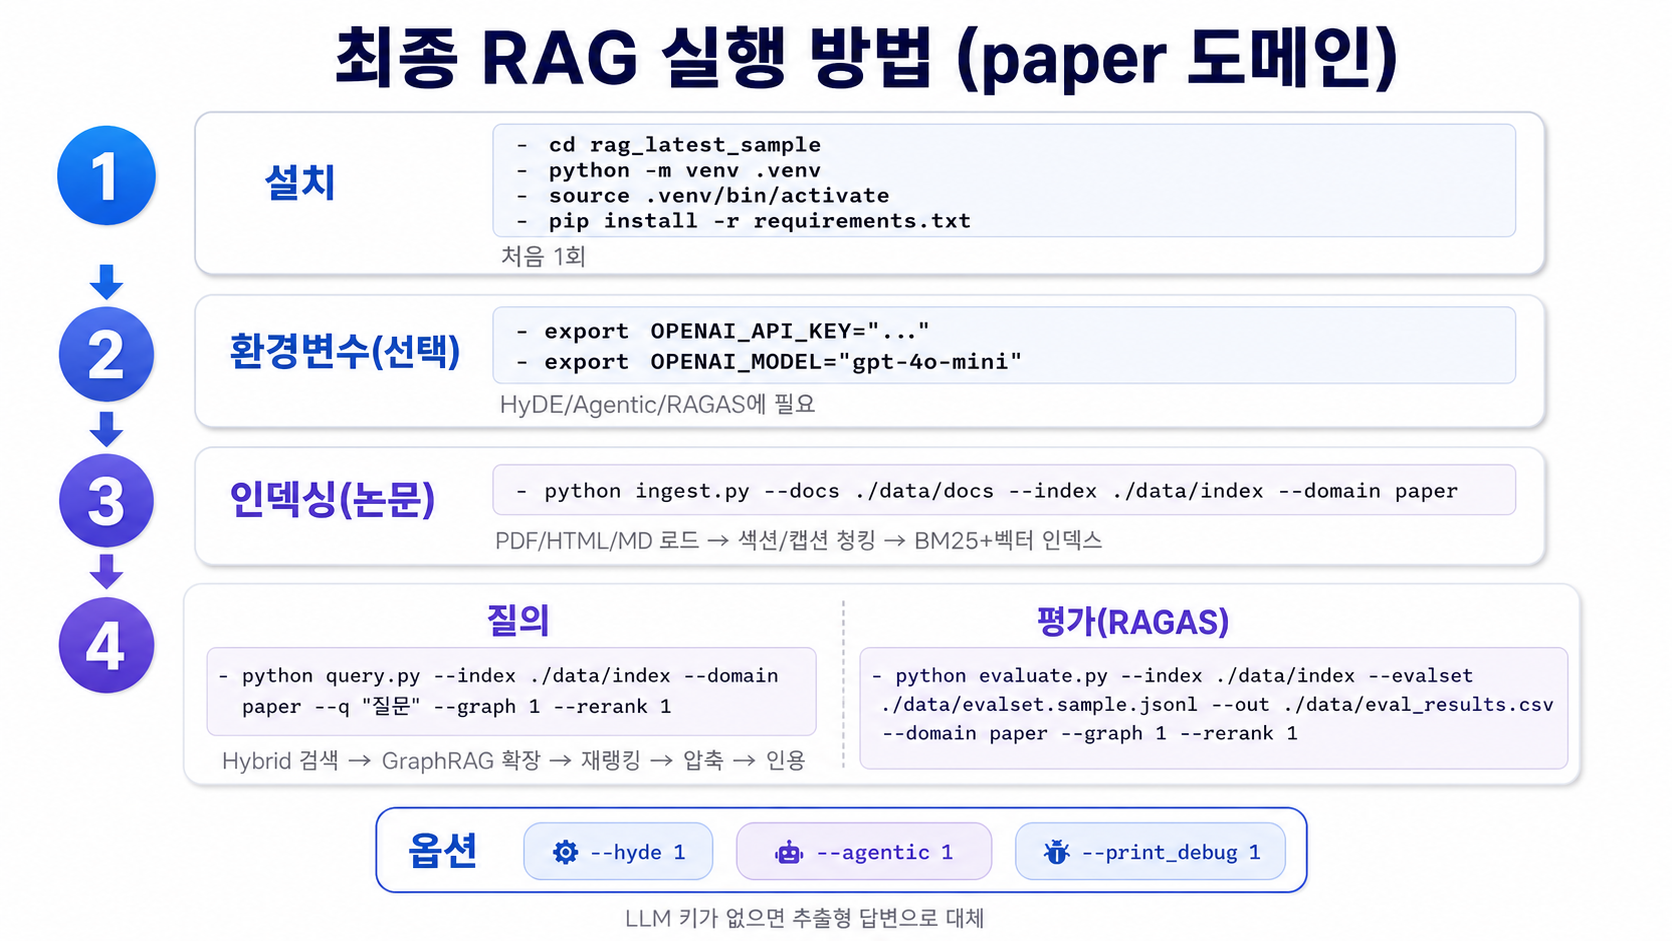

✅ Tool 결과: ✅ Image saved: outputs/generated_images/image_20260804_164654_769.png
최종 RAG 실행 방법을 **인포그래픽(이미지)** 으로 생성했습니다.

- 파일: `outputs/generated_images/image_20260804_164654_769.png`


In [ ]:
result = await stream_print(agent,
                            '''최종 RAG를 실행 하는 방법을 인포그래픽으로 출력해 줘.
                            ''',
                            config=config)